In [1]:
from siman.geo import calc_kspacings

In [2]:
from ase.optimize import FIRE  
from pathlib import Path
import csv
import shutil 
import subprocess
import glob


## Other default imports 

In [3]:
import os, re
import random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from tqdm import tqdm
# from pymatgen.ext.matproj import MPRester
from mp_api.client import MPRester
from pymatgen.core import Composition, Element
from pymatgen.analysis.phase_diagram import GrandPotentialPhaseDiagram, PhaseDiagram
from pymatgen.analysis.interface_reactions import InterfacialReactivity, GrandPotentialInterfacialReactivity
from emmet.core.thermo import ThermoType
from pymatgen.entries.computed_entries import ComputedEntry
from matplotlib.patches import Patch
from pymatgen.core import Structure
from pymatgen.analysis.diffraction.xrd import XRDCalculator
from pathlib import Path



In [4]:
%%capture
import siman #program package to manage DFT calculations https://github.com/dimonaks/siman
from siman.calc_manage import smart_structure_read, get_structure_from_matproj, get_structure_from_matproj_new
from siman.calc_manage import add, res
# Update configurations
from siman import header
from siman.database import write_database, read_database
from siman.set_functions import read_vasp_sets
from siman.header import db
from siman.header import _update_configuration
_update_configuration('project_conf.py')
read_database() # read saved database if available
from pydoc import importfile
project_sets = importfile('project_sets.py')
varset = read_vasp_sets(project_sets.user_vasp_sets, override_global = 1) #read user sets

from siman import thermo

# header.PATH2PROJECT = '../dft_calculations/'
header.PATH2EDITOR = 'notepad.exe'
header.PATH2POTENTIALS = "/home/a.burov/soft/vasp_potentials/potpaw_PBE_MPIE/"

from matplotlib import rc



In [7]:
from ase.optimize import FIRE  
from ase.io import read, write
from ase.visualize import view


In [8]:
from matplotlib import font_manager as fm
font_path = "/home/a.burov/fonts/ARIAL.TTF"
fm.fontManager.addfont(font_path)


In [9]:
pd.set_option('display.max_rows', 500)
pd.set_option('display.max_columns', 500)
pd.set_option('display.width', 1000)

In [10]:
np.set_printoptions(precision=5)


In [11]:
# %matplotlib inline
plt.rcParams['figure.dpi'] = 450


In [12]:
API_KEY = "LTSM6dStBrl69FjopxP7KdZBP35B1yh7"

## Initial relaxation for phonons CSV

In [99]:
layered_groups = ["P1", "P2_1", "P-1", "Pc", "P2_1_c"]

names_list = ["layered_p1", "layered_p-1", "layered_p21", "layered_p2c",
    "layered_p21c", "alpha", "beta", "gamma", "delta"]


In [100]:
for group in layered_groups:
    st = db[f"layered_{group}_final", '9bulk', 1].copy().end
    # add(f"layered_{group}", 'phonons_prio', 1, it_folder = 'phonons', input_st = st, cluster = 'razor128', up='up2', run=2)
    # res(f"layered_{group}", 'phonons_prio', 1, up='up2', cluster="razor128")
            
for st_name in ["alpha", "beta", "gamma", "delta"]:
    st = db[f"{st_name}.sc", '9bulk_eos', 100].copy().end
    # add(f"diaspore_{st_name}", 'phonons_prio', 1, it_folder = 'phonons', input_st = st, cluster = 'razor128', up='up2', run=2)
    # res(f"diaspore_{st_name}", 'phonons_prio', 1, up='up2', cluster="razor128")

    

In [101]:
write_database()


Database has been successfully updated



### Convergence test for phonon frequencies, using P21c space group

In [102]:
colors = ["green", 'red', 'blue', 'magenta', 'black', 'orange',
    # "alignn": [],
    # "nequip": [],
         ]


In [103]:
group = "P2_1_c"

In [104]:
st = db[f"layered_P2_1_c", 'phonons_prio', 1].end


In [105]:
st_diaspore = db[f"diaspore_delta", 'phonons_prio', 1].end


In [106]:
sets = [
    "phonons_ibrion6_300",
    "phonons_ibrion6_400",
    "phonons_ibrion6_500",
    "phonons_ibrion6_600",
    "phonons_ibrion6_700",
    "phonons_ibrion6_800",
    # "phonons_ibrion6_900",
    # "phonons_ibrion6_1000",
]


In [107]:
for set_cur in sets:
    pass
    # add(f"layered_{group}", set_cur, 1, it_folder = 'phonons', input_st = st, cluster = 'razor128', up='up2', run=2)
    # res(f"layered_{group}", set_cur, 1, up='up2')

   
    

In [108]:
write_database()


Database has been successfully updated



In [109]:
elastic_converged  = db[f"layered_{group}", 'phonons_ibrion6_800', 1].eltensor.flatten()


In [110]:
ecut_list = []
max_ae_list = []
rmse_list = []
el_tensor_list = []


In [111]:
for set_cur in sets:
    print(f"SET = {set_cur}")
    el_tensor = db[f"layered_{group}", set_cur, 1].eltensor
    ksp_list.append(max(db[f"layered_{group}", set_cur, 1].calc_kspacings()))
    # RMSE and MaxAE
    rmse = np.sqrt(np.mean((el_tensor.flatten() - elastic_converged)**2))
    max_ae = np.max(np.abs(el_tensor.flatten() - elastic_converged))

    el_tensor_list.append(el_tensor)
    ecut = int(set_cur.split("_")[-1])
    ecut_list.append(ecut)
    # RMSE and MaxAE

    max_ae_list.append(max_ae)
    rmse_list.append(rmse)


    c11 = el_tensor[0][0]
    c22 = el_tensor[1][1]
    c33 = el_tensor[2][2]
    c12 = el_tensor[0][1]
    c13 = el_tensor[0][2]
    c23 = el_tensor[1][2]

    print(f"C11 = {c11:1.2f}")
    print(f"C12 = {c12:1.2f}")
    print(f"C13 = {c13:1.2f}")
    print(f"C22 = {c22:1.2f}")
    print(f"C23 = {c23:1.2f}")
    print(f"C33 = {c33:1.2f}")
    print(f"RMSE = {rmse:1.2f}")
    print(f"MaxAE = {max_ae:1.2f}")
    

SET = phonons_ibrion6_300
C11 = 545.49
C12 = 131.45
C13 = 139.54
C22 = 465.61
C23 = 148.41
C33 = 510.40
RMSE = 122.41
MaxAE = 419.81
SET = phonons_ibrion6_400
C11 = 301.35
C12 = 73.55
C13 = 80.72
C22 = 220.18
C23 = 87.84
C33 = 254.92
RMSE = 43.84
MaxAE = 175.66
SET = phonons_ibrion6_500
C11 = 200.79
C12 = 45.31
C13 = 53.80
C22 = 127.77
C23 = 59.96
C33 = 162.53
RMSE = 18.80
MaxAE = 75.10
SET = phonons_ibrion6_600
C11 = 189.35
C12 = 41.52
C13 = 49.90
C22 = 115.68
C23 = 55.96
C33 = 151.74
RMSE = 17.35
MaxAE = 63.66
SET = phonons_ibrion6_700
C11 = 125.62
C12 = 50.61
C13 = 58.38
C22 = 154.55
C23 = 40.13
C33 = 122.83
RMSE = 0.12
MaxAE = 0.50
SET = phonons_ibrion6_800
C11 = 125.69
C12 = 50.78
C13 = 58.38
C22 = 154.37
C23 = 40.25
C33 = 122.33
RMSE = 0.00
MaxAE = 0.00


In [112]:
write_database()


Database has been successfully updated



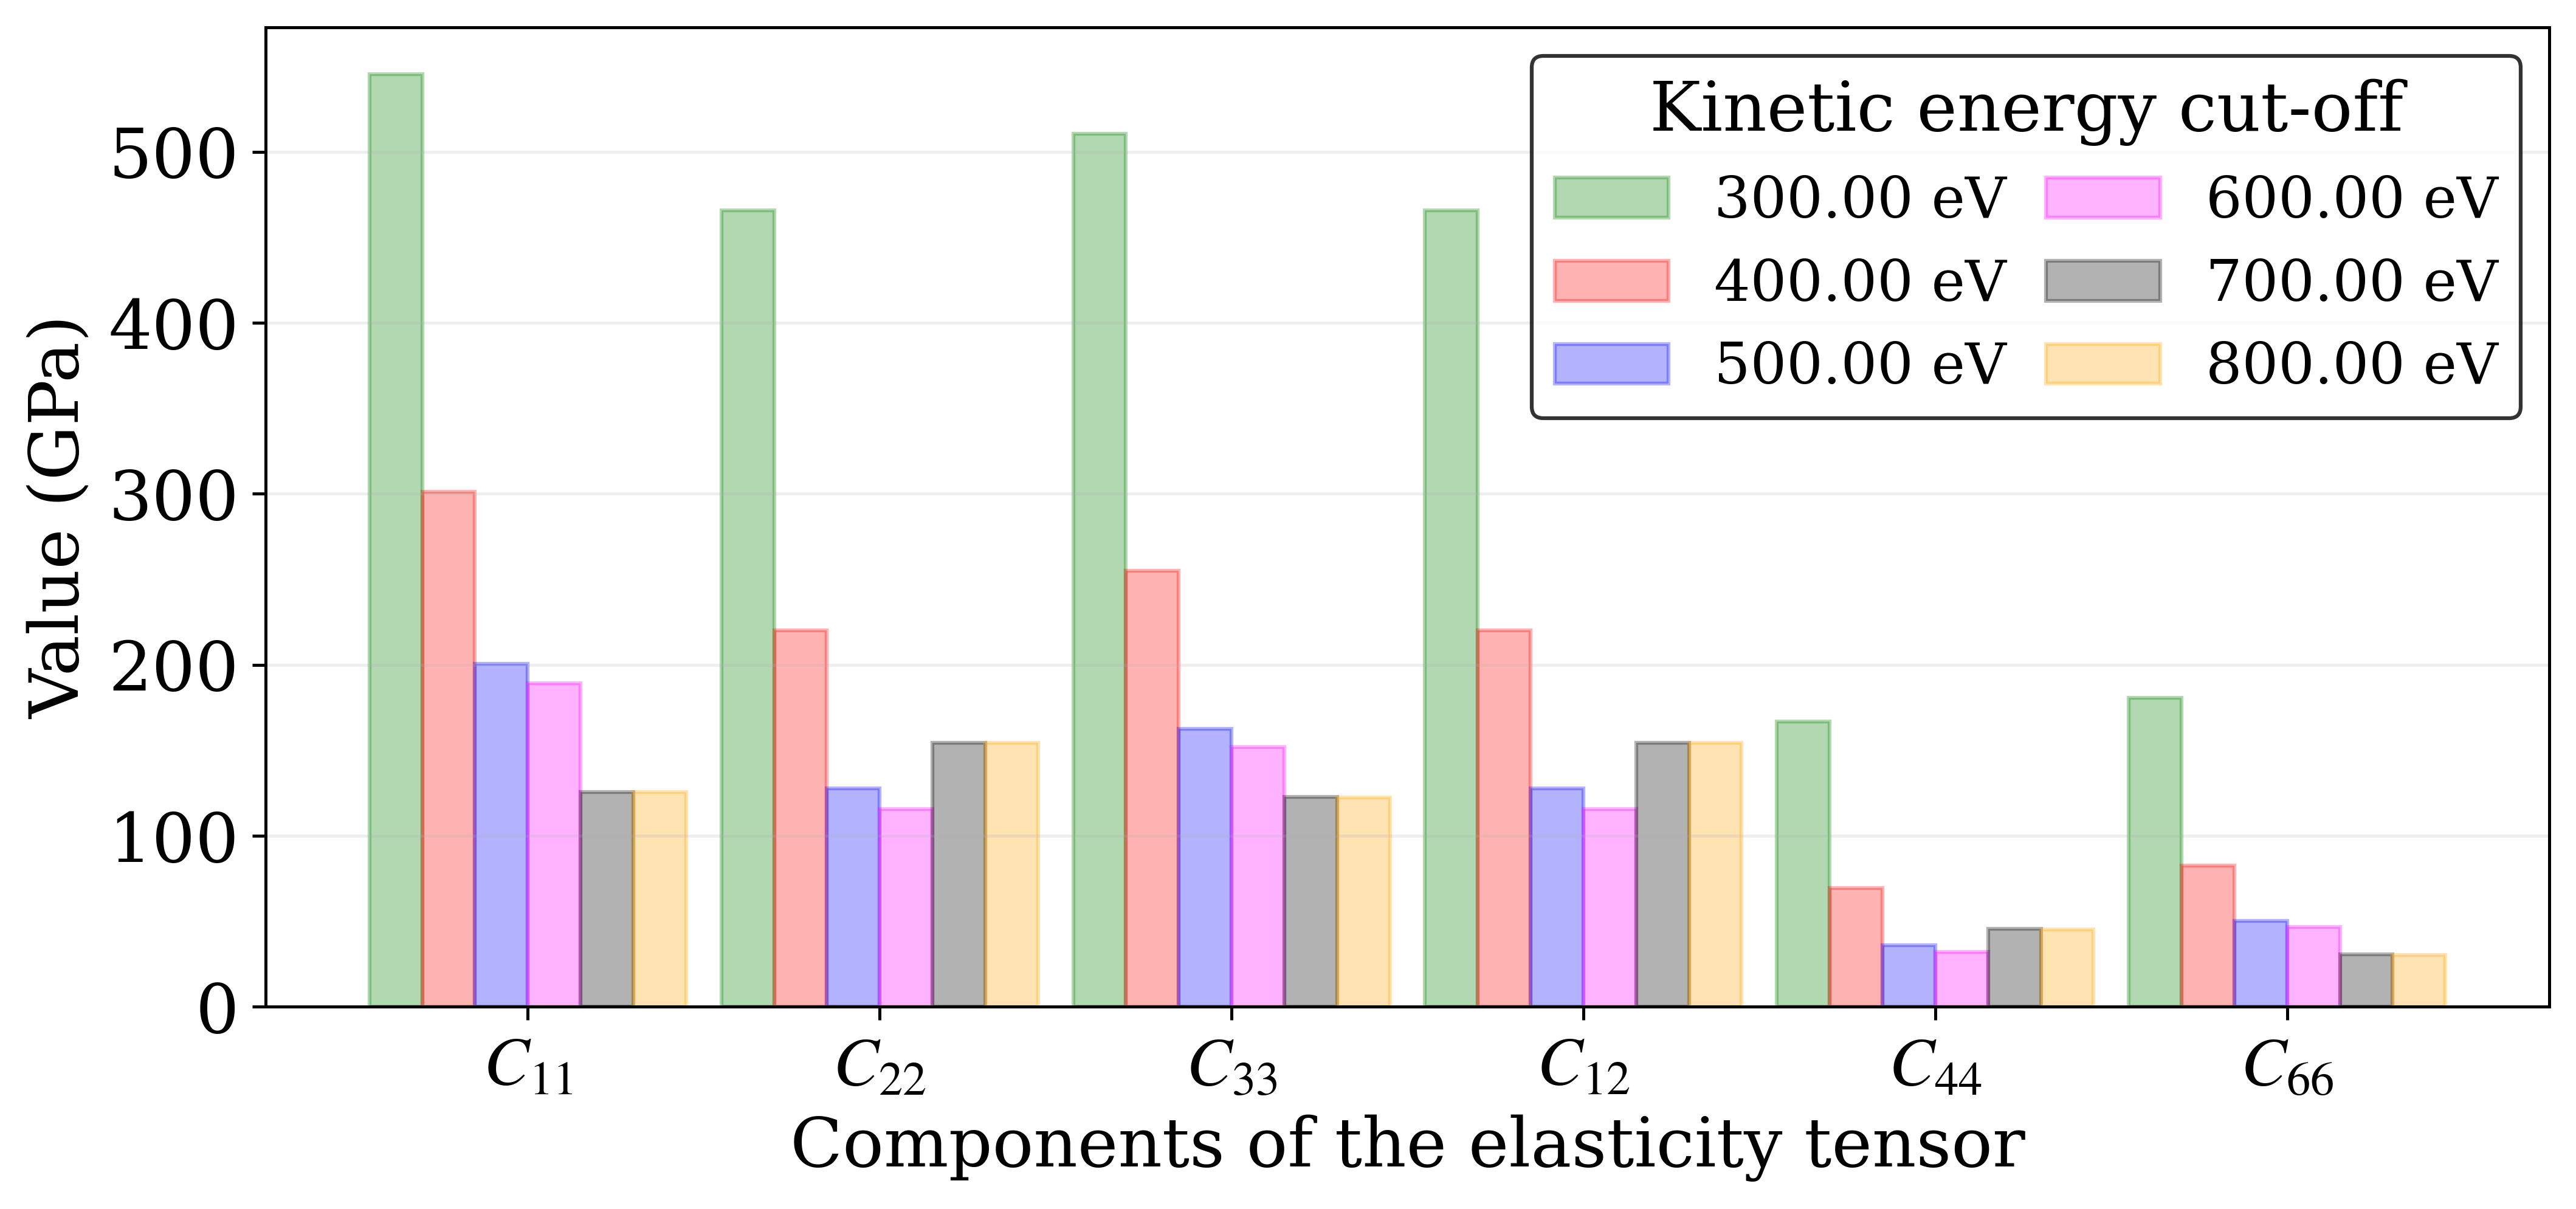

In [114]:
# Primary components
fontsize = 18

# Extract primary values (N_ksp x 6)
prim_values = np.zeros((len(el_tensor_list), len(components)))
for t_idx, tensor in enumerate(el_tensor_list):
    for c_idx, v_idx in enumerate(voigt_idx):
        prim_values[t_idx, c_idx] = tensor[v_idx, v_idx]

# PLOT: X=Cij, grouped bars by ksp
fig, ax = plt.subplots(figsize=(10, 5))
x = np.arange(len(components))
width = 0.15

# colors = plt.cm.viridis(np.linspace(0.2, 0.9, len(ksp_list)))
for i, ecut in enumerate(ecut_list):
    # FIXED: prim_values[i, :] → 1D array of 6 values (one per Cij)
    ax.bar(x + i*width - (len(ecut_list)-1)*width/2, prim_values[i, :], 
           width, label=f"{ecut:.2f} eV", color=colors[i], alpha=0.3, edgecolor=colors[i])

ax.set_xlabel('Components of the elasticity tensor', fontsize=fontsize)
ax.set_ylabel('Value (GPa)', fontsize=fontsize)
ax.tick_params(axis='both', which='major', labelsize=fontsize)
ax.tick_params(axis='both', which='minor', labelsize=fontsize-2)
ax.set_xticks(x)
ax.set_xticklabels(components)
legend = ax.legend(title=f"Kinetic energy cut-off", loc=1, fontsize=fontsize-3, columnspacing=0.7, edgecolor='black', ncols=2)
legend.get_title().set_fontsize(fontsize)
ax.grid(True, alpha=0.2, axis='y')

plt.tight_layout()
plt.savefig('/home/a.burov/icys_2025/niohf/data/figures/elastic_convergence_ecut.png', dpi=450, bbox_inches='tight')
plt.savefig('/home/a.burov/icys_2025/niohf/data/figures/elastic_convergence_ecut.pdf', dpi=450, bbox_inches='tight')

plt.show()


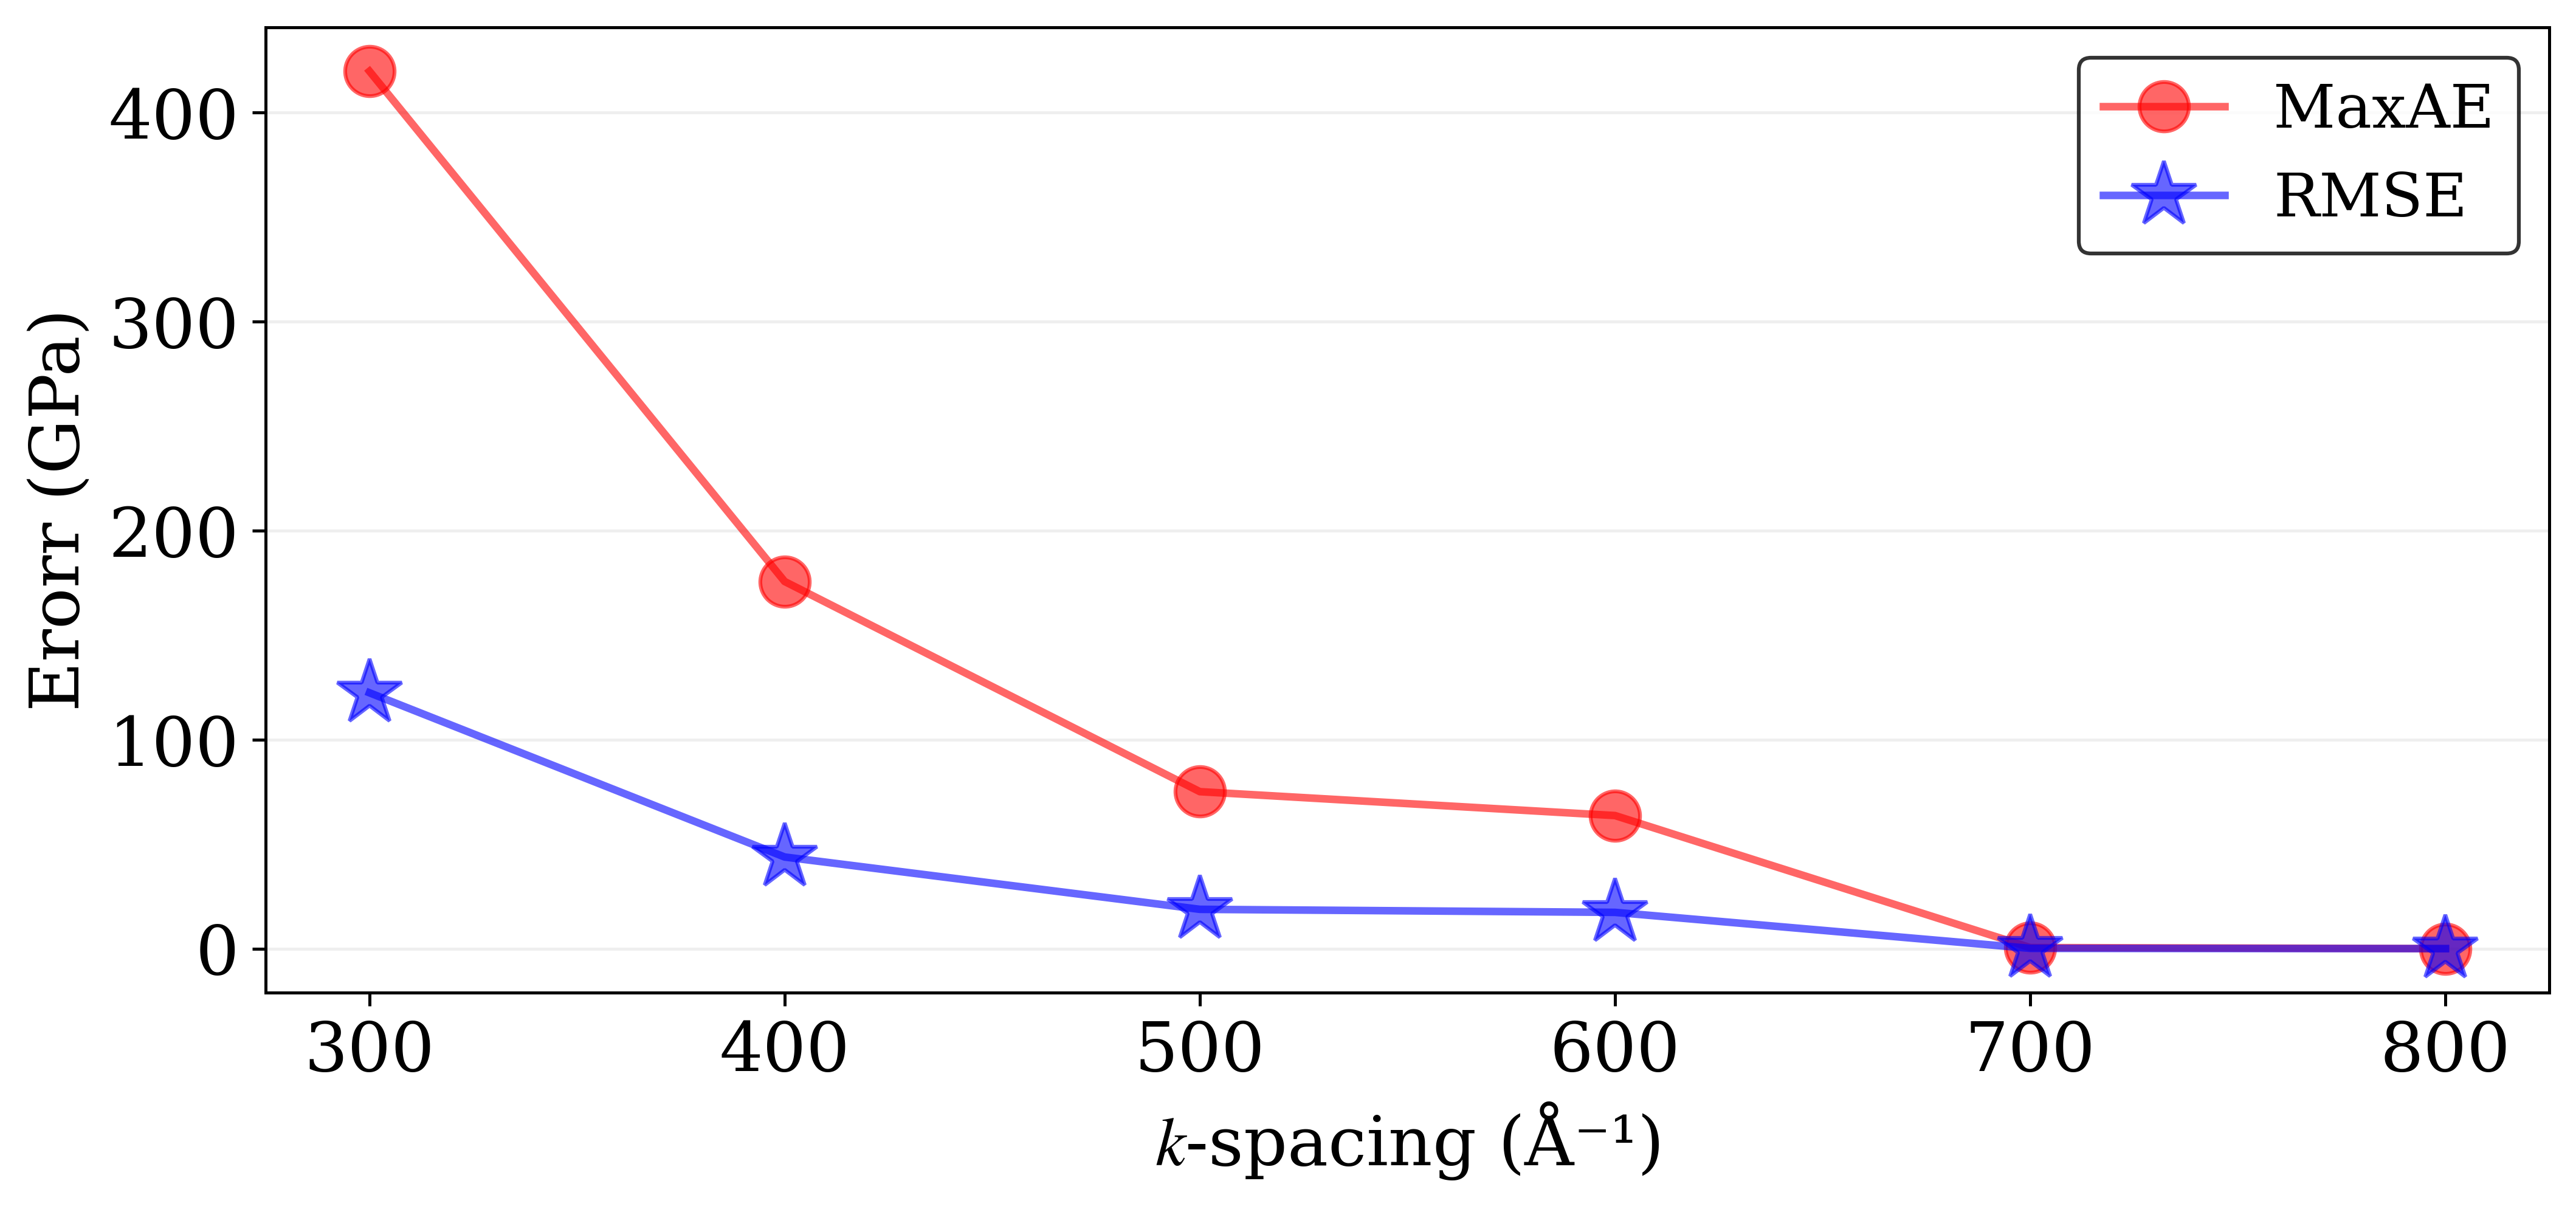

In [115]:
# Primary components
fontsize = 18

fig, ax = plt.subplots(figsize=(10, 5))

# colors = plt.cm.viridis(np.linspace(0.2, 0.9, len(ksp_list)))
ax.plot(ecut_list, np.array(max_ae_list), '-o', markersize=13, color="red", lw=2, alpha=0.6, label="MaxAE")
ax.plot(ecut_list, np.array(rmse_list), '-*', markersize=18, color="blue", lw=2, alpha=0.6, label="RMSE")

ax.set_xlabel(f"$k$-spacing (Å⁻¹)", fontsize=fontsize)
ax.set_ylabel('Erorr (GPa)', fontsize=fontsize)
ax.tick_params(axis='both', which='major', labelsize=fontsize)
ax.tick_params(axis='both', which='minor', labelsize=fontsize-2)
legend = ax.legend(loc=1, fontsize=fontsize-2, edgecolor='black')
ax.grid(True, alpha=0.2, axis='y')

plt.tight_layout()
plt.savefig('/home/a.burov/icys_2025/niohf/data/figures/elastic_convergence_ecut_errors.png', dpi=450, bbox_inches='tight')
plt.savefig('/home/a.burov/icys_2025/niohf/data/figures/elastic_convergence_ecut_errors.pdf', dpi=450, bbox_inches='tight')

plt.show()


## K-spacing

In [116]:

calc_kspacings([1,1,1], st.rprimd)

[1.2690452031284278, 1.0093778456177114, 1.3402909813388513]

In [117]:
group = "P2_1_c"

In [118]:
sets_kp = [
    "phonons_ibrion6_ksp_1",
    "phonons_ibrion6_ksp_07",
    "phonons_ibrion6_ksp_035",
    "phonons_ibrion6_ksp_02",
    "phonons_ibrion6_ksp_015",
    # "phonons_ibrion6_ksp_01",
    
 ]



In [119]:
for set_cur in sets_kp:
    pass
    # add(f"layered_{group}", set_cur, 1, it_folder = 'phonons', input_st = st, cluster = 'razor128', up='up2', run=2)
    # res(f"layered_{group}", set_cur, 1, up='up2')
    

In [120]:
elastic_converged  = db[f"layered_{group}", 'phonons_ibrion6_ksp_015', 1].eltensor.flatten()


In [121]:
data = db[f"layered_{group}", 'phonons_ibrion6_ksp_035', 1].check_kpoints()
       

-- check_kpoints(): Kpoint   mesh is:  [6, 4, 2] 

-- check_kpoints(): The actual k-spacings are  ['0.34', '0.34', '0.31'] 



In [122]:
data

[6, 4, 2]

In [123]:
# print( db[f"layered_{group}", 'phonons_ibrion6_ksp_035', 1].check_kpoints()[2] ) 


In [124]:
# dir( db[f"layered_{group}", 'phonons_ibrion6_ksp_035', 1] ) 


In [125]:
ksp_list = []
max_ae_list = []
rmse_list = []
el_tensor_list = []

In [135]:
for set_cur in sets_kp:
    print(f"SET = {set_cur}")
    el_tensor = db[f"layered_{group}", set_cur, 1].eltensor
    el_tensor_list.append(el_tensor)
    ksp_list.append(max(db[f"layered_{group}", set_cur, 1].calc_kspacings()))
    # RMSE and MaxAE
    rmse = np.sqrt(np.mean((el_tensor.flatten() - elastic_converged)**2))
    max_ae = np.max(np.abs(el_tensor.flatten() - elastic_converged))

    max_ae_list.append(max_ae)
    rmse_list.append(rmse)

    c11 = el_tensor[0][0]
    c22 = el_tensor[1][1]
    c33 = el_tensor[2][2]
    c12 = el_tensor[0][1]
    c13 = el_tensor[0][2]
    c23 = el_tensor[1][2]

    print(f"C11 = {c11:1.2f}")
    print(f"C12 = {c12:1.2f}")
    print(f"C13 = {c13:1.2f}")
    print(f"C22 = {c22:1.2f}")
    print(f"C23 = {c23:1.2f}")
    print(f"C33 = {c33:1.2f}")
    print(f"RMSE = {rmse:1.2f}")
    print(f"MaxAE = {max_ae:1.2f}")
    

SET = phonons_ibrion6_ksp_1
C11 = 173.21
C12 = 46.91
C13 = 53.94
C22 = 120.57
C23 = 57.28
C33 = 157.03
RMSE = 0.25
MaxAE = 1.24
SET = phonons_ibrion6_ksp_07
C11 = 171.92
C12 = 47.01
C13 = 54.14
C22 = 120.33
C23 = 57.26
C33 = 156.91
RMSE = 0.10
MaxAE = 0.35
SET = phonons_ibrion6_ksp_035
C11 = 171.85
C12 = 47.22
C13 = 54.22
C22 = 120.61
C23 = 57.24
C33 = 157.02
RMSE = 0.09
MaxAE = 0.26
SET = phonons_ibrion6_ksp_02
C11 = 171.96
C12 = 47.26
C13 = 54.12
C22 = 120.50
C23 = 57.17
C33 = 156.68
RMSE = 0.14
MaxAE = 0.58
SET = phonons_ibrion6_ksp_015
C11 = 171.97
C12 = 47.20
C13 = 54.41
C22 = 120.35
C23 = 57.41
C33 = 157.26
RMSE = 0.00
MaxAE = 0.00


In [127]:
# len(el_tensor_list)

In [128]:
# ksp_list

In [129]:
write_database()


Database has been successfully updated



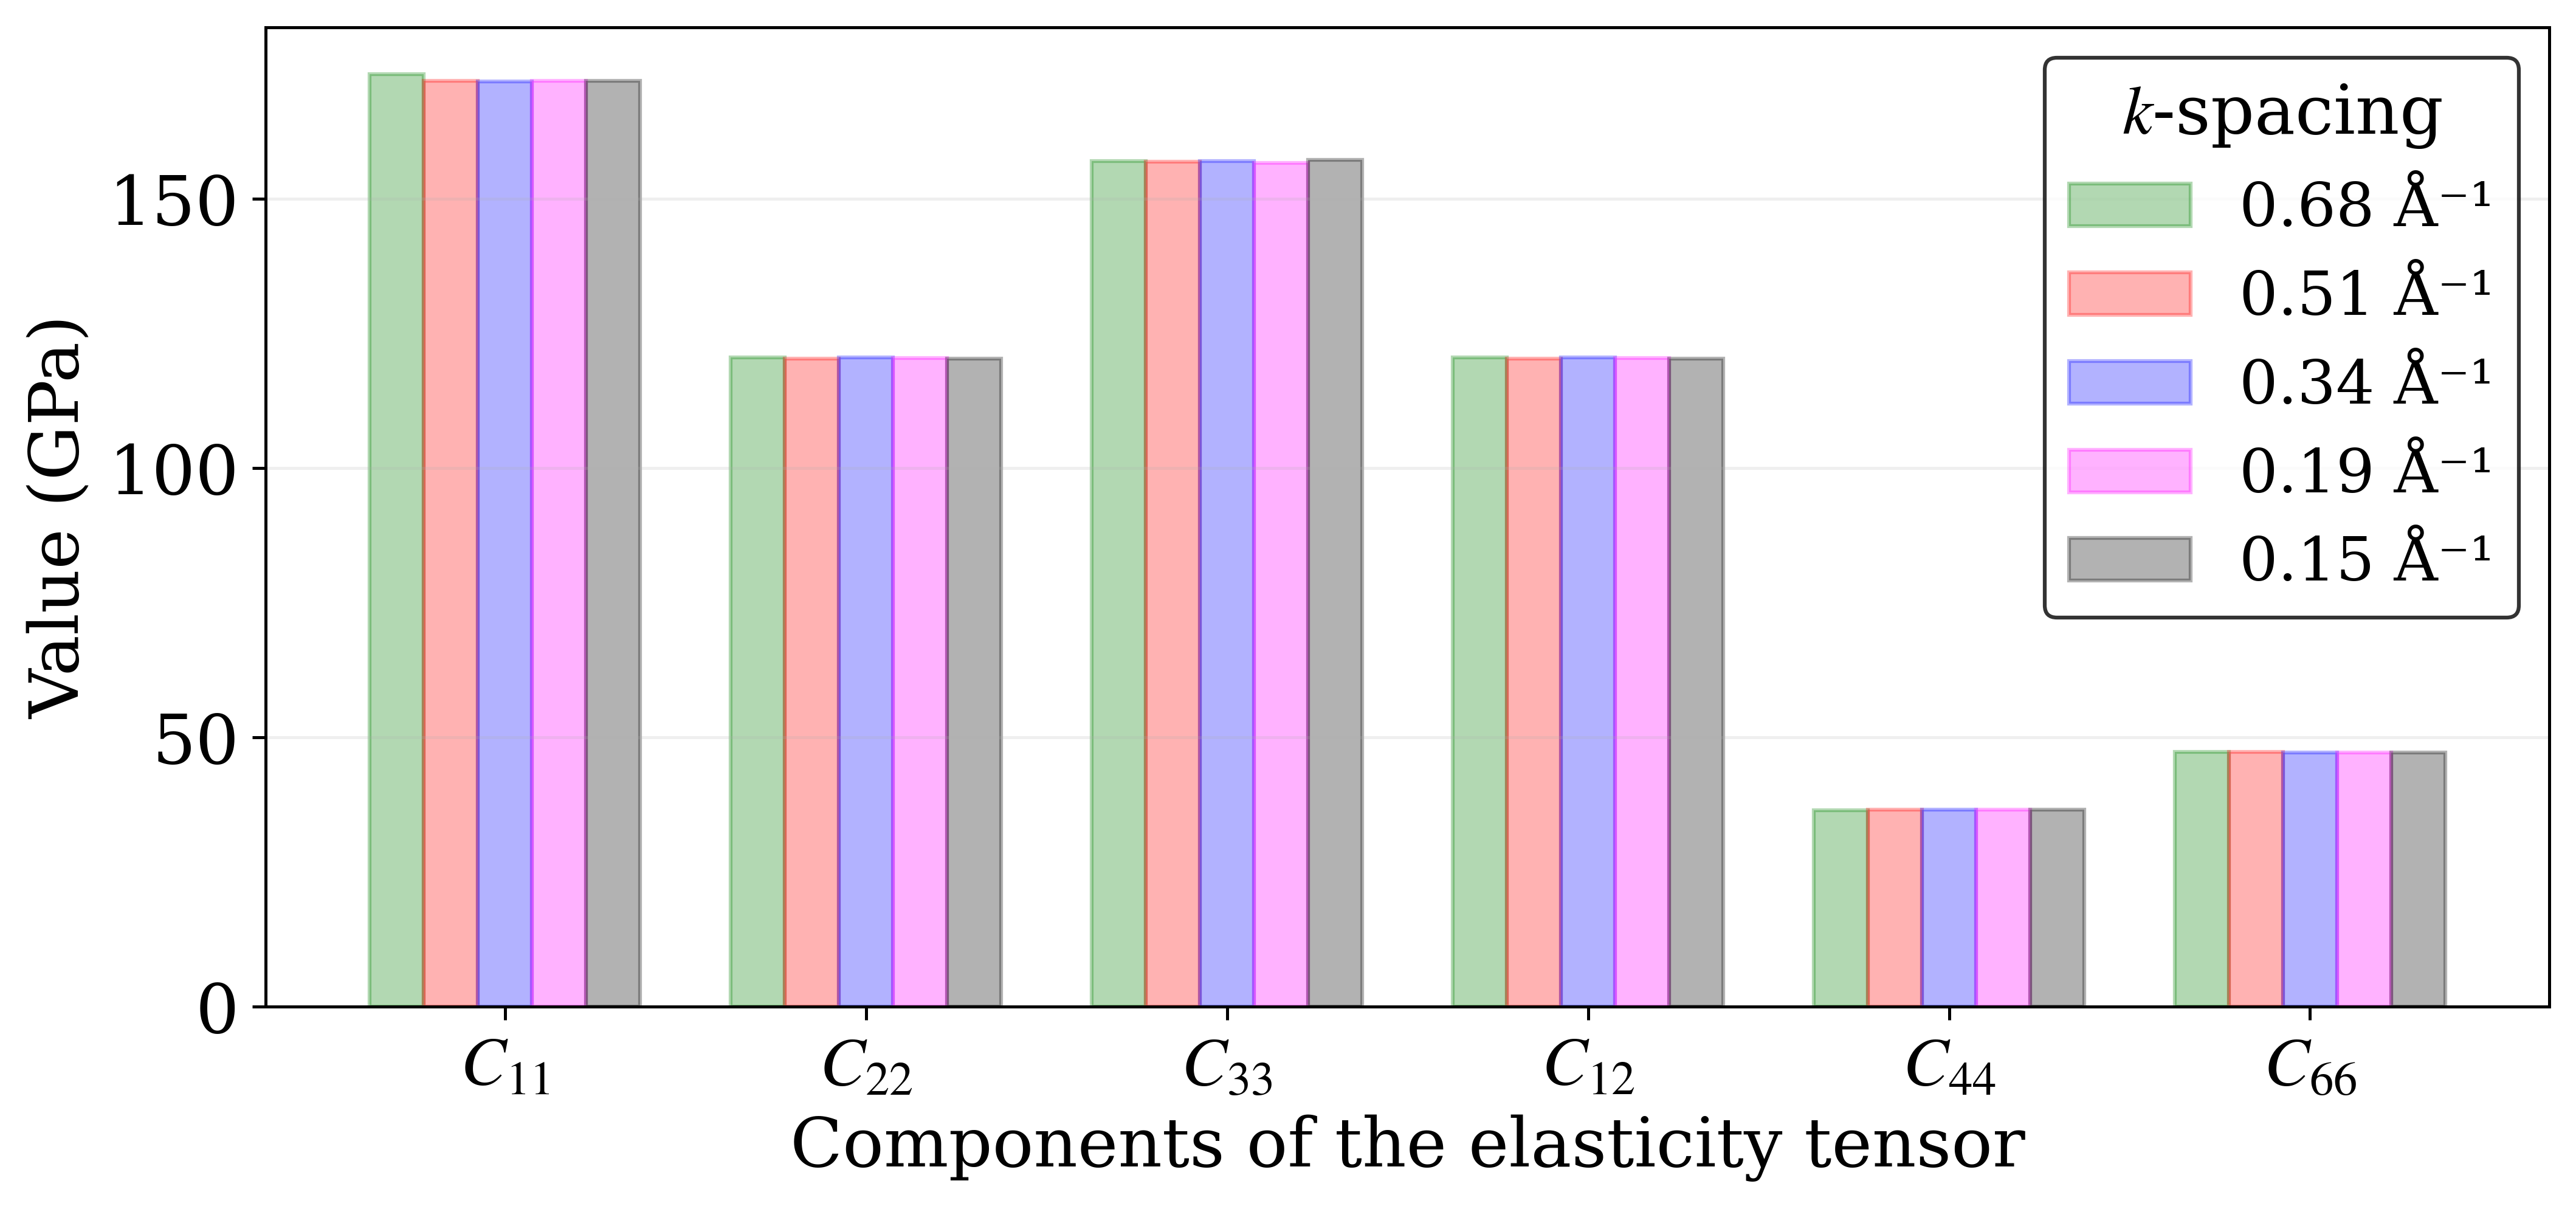

In [130]:
# Primary components
components = [r'$C_{11}$', r'$C_{22}$', r'$C_{33}$', r'$C_{12}$', r'$C_{44}$', r'$C_{66}$']
voigt_idx = [0, 1, 2, 1, 3, 5]
fontsize = 18

# Extract primary values (N_ksp x 6)
prim_values = np.zeros((len(el_tensor_list), len(components)))
for t_idx, tensor in enumerate(el_tensor_list):
    for c_idx, v_idx in enumerate(voigt_idx):
        prim_values[t_idx, c_idx] = tensor[v_idx, v_idx]

# PLOT: X=Cij, grouped bars by ksp
fig, ax = plt.subplots(figsize=(10, 5))
x = np.arange(len(components))
width = 0.15

# colors = plt.cm.viridis(np.linspace(0.2, 0.9, len(ksp_list)))
for i, ksp in enumerate(ksp_list):
    # FIXED: prim_values[i, :] → 1D array of 6 values (one per Cij)
    ax.bar(x + i*width - (len(ksp_list)-1)*width/2, prim_values[i, :], 
           width, label=f"{ksp:.2f} Å⁻¹", color=colors[i], alpha=0.3, edgecolor=colors[i])

ax.set_xlabel('Components of the elasticity tensor', fontsize=fontsize)
ax.set_ylabel('Value (GPa)', fontsize=fontsize)
ax.tick_params(axis='both', which='major', labelsize=fontsize)
ax.tick_params(axis='both', which='minor', labelsize=fontsize-2)
ax.set_xticks(x)
ax.set_xticklabels(components)
legend = ax.legend(title=f"$k$-spacing", loc=1, fontsize=fontsize-2, edgecolor='black')
legend.get_title().set_fontsize(fontsize)
ax.grid(True, alpha=0.2, axis='y')

plt.tight_layout()
plt.savefig('/home/a.burov/icys_2025/niohf/data/figures/elastic_convergence_ksp.png', dpi=450, bbox_inches='tight')
plt.savefig('/home/a.burov/icys_2025/niohf/data/figures/elastic_convergence_ksp.pdf', dpi=450, bbox_inches='tight')

plt.show()


In [131]:
max_ae_list

[1.2363599999999906,
 0.34826000000001045,
 0.26156999999997765,
 0.5838699999999903,
 0.0]

In [132]:
ksp_list

[0.683598175012652,
 0.512698631259489,
 0.341799087506326,
 0.1932305607417383,
 0.14648532321699687]

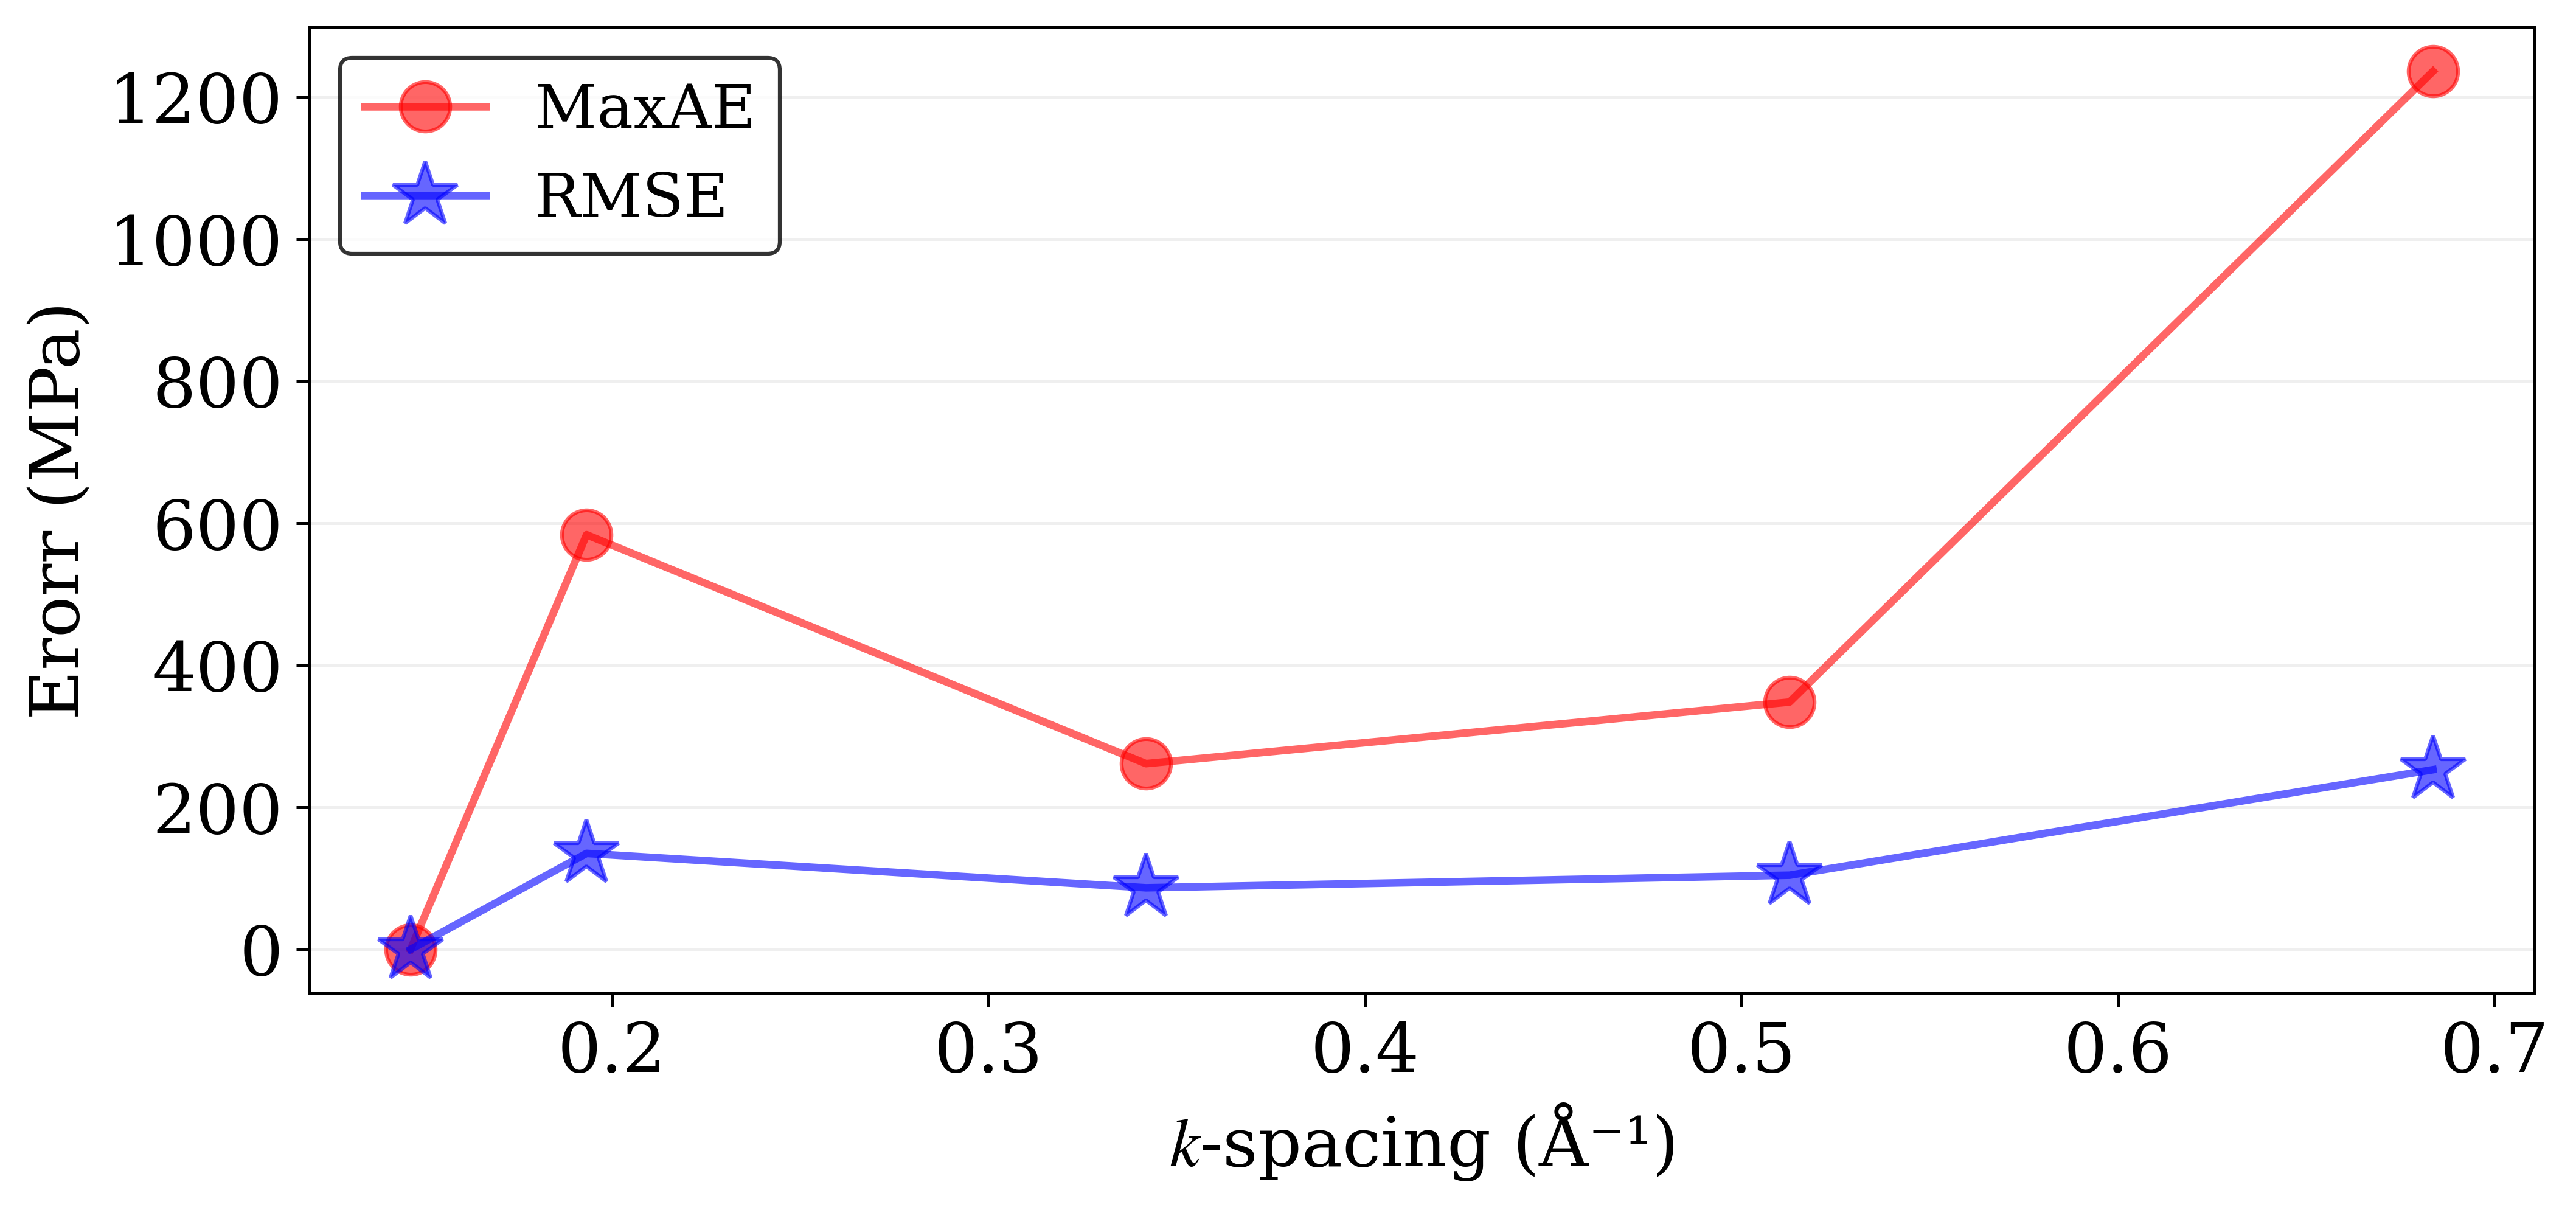

In [133]:
# Primary components
fontsize = 18

fig, ax = plt.subplots(figsize=(10, 5))

# colors = plt.cm.viridis(np.linspace(0.2, 0.9, len(ksp_list)))
ax.plot(ksp_list, np.array(max_ae_list)*1e3, '-o', markersize=13, color="red", lw=2, alpha=0.6, label="MaxAE")
ax.plot(ksp_list, np.array(rmse_list)*1e3, '-*', markersize=18, color="blue", lw=2, alpha=0.6, label="RMSE")

ax.set_xlabel(f"$k$-spacing (Å⁻¹)", fontsize=fontsize)
ax.set_ylabel('Erorr (MPa)', fontsize=fontsize)
ax.tick_params(axis='both', which='major', labelsize=fontsize)
ax.tick_params(axis='both', which='minor', labelsize=fontsize-2)
legend = ax.legend(loc=2, fontsize=fontsize-2, edgecolor='black')
ax.grid(True, alpha=0.2, axis='y')

plt.tight_layout()
plt.savefig('/home/a.burov/icys_2025/niohf/data/figures/elastic_convergence_ksp_errors.png', dpi=450, bbox_inches='tight')
plt.savefig('/home/a.burov/icys_2025/niohf/data/figures/elastic_convergence_ksp_errors.pdf', dpi=450, bbox_inches='tight')

plt.show()


## Final relaxation of structures

In [11]:
layered_groups = ["P1", "P2_1", "P-1", "Pc", "P2_1_c"]

names_list = ["layered_p1", "layered_p-1", "layered_p21", "layered_p2c",
    "layered_p21c", "alpha", "beta", "gamma", "delta"]


In [12]:
for group in layered_groups:
    st = db[f"layered_{group}_final", '9bulk', 1].copy().end
    # add(f"layered_{group}", 'phonons_setup_rel', 1, it_folder = 'phonons', input_st = st, cluster = 'razor128', up='up2', run=2)
    # add(f"layered_{group}", 'phonons_setup_eos', 1, it_folder = 'phonons', input_st = st, cluster = 'razor128', up='up2', run=2,
    #    calc_method = 'c_scale', n_scale_images=10, scale_region = (-5, 10))
    
    # res(f"layered_{group}", 'phonons_prio', 1, up='up2', cluster="razor128")  
    # res(f"layered_{group}.sc", 'phonons_setup_eos', list(range(1,11)) + [100], show = 'fit', analys_type = 'fit_a', up="up2", cluster = 'razor128')
            
for st_name in ["alpha", "beta", "gamma", "delta"]:
    st = db[f"{st_name}.sc", '9bulk_eos', 100].copy().end
    # add(f"diaspore_{st_name}", 'phonons_setup_rel', 1, it_folder = 'phonons', input_st = st, cluster = 'razor128', up='up2', run=2)
    # add(f"diaspore_{st_name}", 'phonons_setup_eos', 1, it_folder = 'phonons', input_st = st, cluster = 'razor128', up='up2', run=2,
    #    calc_method = 'uniform_scale', n_scale_images=10, scale_region = (-8, 8))
    
    # res(f"diaspore_{st_name}.su", 'phonons_setup_eos', list(range(1,11)) + [100], show = 'fit', analys_type = 'fit_a', up="up2", cluster = 'razor128')
    # res(f"diaspore_{st_name}.su", 'phonons_setup_eos', list(range(1,11)) + [100], show = 'fit', analys_type = 'fit_a', up="up2", cluster = 'razor128')


    

In [13]:
write_database()


Database has been successfully updated



## Relaxation of supercells

In [85]:
layered_groups = ["P1", "P2_1", "P-1", "Pc", "P2_1_c"]

names_list = ["layered_p1", "layered_p-1", "layered_p21", "layered_p2c",
    "layered_p21c", "alpha", "beta", "gamma", "delta"]


In [48]:
for group in layered_groups:
    st = db[f"layered_{group}_final", '9bulk', 1].copy().end
    st_super = st.replic([2, 2, 2])
    # print(st_super.rprimd)
    # add(f"layered_{group}", 'phonons_setup_rel', 1, it_folder = 'phonons', input_st = st_super, ngkpt=[1,1,1], cluster = 'razor128', up='up2', run=2)
    # add(f"layered_{group}", 'phonons_setup_eos', 1, it_folder = 'phonons', input_st = st_super, ngkpt=[1,1,1], cluster = 'razor128', up='up2', run=2,
    #    calc_method = 'c_scale', n_scale_images=6, scale_region = (-3, 10))

    # res(f"layered_{group}", 'phonons_setup_rel', 1, up='up2', cluster="razor128")
    # res(f"layered_{group}.sc", 'phonons_setup_eos', list(range(1,7)) + [100], show = 'fit', analys_type = 'fit_a', up="up2", cluster = 'razor128')
    # res(f"layered_{group}.sc", 'phonons_setup_eos', 100, up="up2", cluster = 'razor128')

    
# for st_name in ["alpha", "beta", "gamma", "delta"]:
# for st_name in [ "alpha", "gamma", "delta"]:
for st_name in [ "beta"]:
    
    st = db[f"{st_name}.sc", '9bulk_eos', 100].copy().end
    st_super = st.replic([4, 3, 1])
    # add(f"diaspore_{st_name}", 'phonons_setup_rel', 1, it_folder = 'phonons', input_st = st_super, ngkpt=[1,1,1], cluster = 'razor128', up='up2', run=2)
    # add(f"diaspore_{st_name}", 'phonons_setup_eos', 1, it_folder = 'phonons', input_st = st_super, ngkpt=[1,1,1], cluster = 'razor128', up='up2', run=2,
    #    calc_method = 'uniform_scale', n_scale_images=6, scale_region = (-3, 8))

    # res(f"diaspore_{group}", 'phonons_setup_rel', 1, up='up2', cluster="razor128")
    # res(f"diaspore_{st_name}.su", 'phonons_setup_eos', list(range(1,7)) + [100], show = 'fit', analys_type = 'fit_a', up="up2", cluster = 'razor128')
    # for i in  list(range(1,7)) + [100]:
    #     res(f"diaspore_{st_name}.su", 'phonons_setup_eos', i, cluster = 'razor128')
        # print(db[f"diaspore_{st_name}.su", 'phonons_setup_eos', i].end.rprimd, i)
        
    # res(f"diaspore_{st_name}.su", 'phonons_setup_eos', 100, up="up2", cluster = 'razor128')


In [49]:
write_database()


Database has been successfully updated



## Phonopy calculations

### Diaspore structures

In [10]:
path_main = "/home/a.burov/icys_2025/niohf/phonopy_calc/"

In [11]:
path_incar_diaspore = "/home/a.burov/icys_2025/niohf/inputs/diaspore/INCAR"
path_kpoints_diaspore = "/home/a.burov/icys_2025/niohf/inputs/diaspore/KPOINTS"
path_run_diaspore = "/home/a.burov/icys_2025/niohf/inputs/diaspore/diaspore.run"
path_potcar_diaspore = "/home/a.burov/icys_2025/niohf/inputs/diaspore/POTCAR"


In [12]:
# db[f"diaspore_beta.su", 'phonons_setup_eos', 100].copy().end.printme()


In [ ]:
# for st_name in ["alpha", "beta", "gamma", "delta"]:
for st_name in ["delta", ]:
    calc = db[f"diaspore_{st_name}.su", 'phonons_setup_eos', 100].copy()
    path_cur = path_main + f"diaspore_{st_name}"
    os.makedirs(path_cur, exist_ok=True)
    
    # for i in list(range(1,7,1)) + [100]:
    for i in list(range(1,7,1)) + [100]:
        # print(i)
        # need to be adjested to the supercell
        calc = db[f"diaspore_{st_name}.su", 'phonons_setup_eos', i].copy()
        st = db[f"diaspore_{st_name}.su", 'phonons_setup_eos', i].copy().end
        
        path_file = calc.path['output'].replace(f"{i}.OUTCAR", f"{i}.CONTCAR")
        
        path_cur = path_main + f"diaspore_{st_name}/vol_{i}"
        os.makedirs(path_cur, exist_ok=True)
        
        # Construct the full destination path with new name
        dest_file = os.path.join(path_cur, "POSCAR")
        # Copy the file
        shutil.copy(path_file, dest_file)
        print(path_file, dest_file)

        # print(path_file, dest_file)

        # run phonopy command 
        subprocess.run(["phonopy", "-d", "--dim", "1", "1", "1", "--pa", "auto"], cwd=path_cur)
        # print(path_cur)
        
        files = glob.glob(f"{path_cur}/POSCAR-*")
        files += [f"{path_cur}/SPOSCAR"]
        for file in files:
            file_name = file.split("/")[-1]
            if "SPOSCAR" in file_name:
                dir_name = "0"  # SPOSCAR → dir 0
            else:
                dir_name = file_name.replace("POSCAR-", "").zfill(3)  # POSCAR-001 → "001"

            # path_create = f"{path_cur}/{file_name}"
            path_create = f"{path_cur}/{dir_name}" 
            # print(path_create)
            
            os.makedirs(path_create, exist_ok=True)

            # copy poscar files to the destination
            dest_file = os.path.join(path_create, "POSCAR")
            shutil.move(file, dest_file)

            # copy input files
            shutil.copy(path_incar_diaspore, f"{path_create}/")
            shutil.copy(path_kpoints_diaspore, f"{path_create}/")
            shutil.copy(path_potcar_diaspore, f"{path_create}/")
            shutil.copy(path_run_diaspore, f"{path_create}/")
            
            # run vasp
            if 0:
                script_path = f"{path_create}/diaspore.run"
                result = subprocess.run(
                        ["sbatch", script_path],
                        cwd=path_create,
                        capture_output=False,
                        text=True
                    )
            
        # print(path)
        


phonons//diaspore_delta.su.phonons_setup_eos/1.CONTCAR /home/a.burov/icys_2025/niohf/phonopy_calc/diaspore_delta/vol_1/POSCAR
        _
  _ __ | |__   ___  _ __   ___   _ __  _   _
 | '_ \| '_ \ / _ \| '_ \ / _ \ | '_ \| | | |
 | |_) | | | | (_) | | | | (_) || |_) | |_| |
 | .__/|_| |_|\___/|_| |_|\___(_) .__/ \__, |
 |_|                            |_|    |___/
                                      2.44.0

-------------------------[time 2026-02-12 18:33:19]-------------------------
Compiled with OpenMP support (max 128 threads).
Python version 3.10.0
Spglib version 2.5.0

Crystal structure was read from "POSCAR".
Unit of length: angstrom
Displacements creation mode
  Systematic displacements
Settings:
  Supercell: [1 1 1]
  Primitive matrix (Auto):
    [0.25 0.   0.  ]
    [0.         0.33333333 0.        ]
    [0. 0. 1.]
Spacegroup: Pmc2_1 (26)
Number of symmetry operations in supercell: 48
Use -v option to watch primitive cell, unit cell, and supercell structures.

Generated number o

In [13]:
# script_path = "/home/a.burov/icys_2025/niohf/phonopy_calc/diaspore_alpha/vol_1/0/diaspore.run"
# script_dir = "/home/a.burov/icys_2025/niohf/phonopy_calc/diaspore_alpha/vol_1/0/"


# result = subprocess.run(
#     ["sbatch", script_path],
#     cwd=script_dir,
#     capture_output=False,
#     text=True
# )



In [ ]:
# kspacing will be [0.25, 0.22, 0.3]

In [71]:
st = db[f"layered_{group}_final", '9bulk', 1].copy().end

In [82]:
st = db[f"{st_name}.sc", '9bulk_eos', 100].copy().end


In [87]:
# st_super = st.copy().replic([2,2,2])
st_super = st.copy().replic([4,3,1])


In [88]:
calc_kspacings([1,1,1], st_super.rprimd)

[np.float64(0.512698631259489),
 np.float64(0.45087130839738937),
 np.float64(0.6176670189754575)]

In [29]:
write_database()



Database has been successfully updated



### Layered structures

In [12]:
path_main = "/home/a.burov/icys_2025/niohf/phonopy_calc/"

In [13]:
path_incar_layered = "/home/a.burov/icys_2025/niohf/inputs/layered/INCAR"
path_kpoints_layered = "/home/a.burov/icys_2025/niohf/inputs/layered/KPOINTS"
path_run_layered = "/home/a.burov/icys_2025/niohf/inputs/layered/layered.run"
path_potcar_layered = "/home/a.burov/icys_2025/niohf/inputs/layered/POTCAR"


In [14]:
layered_groups = ["P1", "P2_1", "P-1", "Pc", "P2_1_c"]
layered_groups = ["P1", "P-1", "Pc", "P2_1", ]


In [15]:
st = db[f"layered_P1.sc", 'phonons_setup_eos', 100].copy().end


In [16]:
st.get_formula()

'Ni32 H32 O32 F32'

In [17]:
# for group in layered_groups:
for group in ["P2_1_c", "P-1", "P2_1", "Pc"]:
    calc = db[f"layered_{group}.sc", 'phonons_setup_eos', 100].copy().end
    path_cur = path_main + f"layered_{group}"
    os.makedirs(path_cur, exist_ok=True)
    
    # for i in list(range(1,8,1)) + [100]:
    for i in [100]:
    # for i in [1]:
        # print(i)
        calc = db[f"layered_{group}.sc", 'phonons_setup_eos', i].copy()
        st = db[f"layered_{group}.sc", 'phonons_setup_eos', i].copy().end
        
        path_file = calc.path['output'].replace(f"{i}.OUTCAR", f"{i}.CONTCAR")
        
        path_cur = path_main + f"layered_{group}/vol_{i}"
        os.makedirs(path_cur, exist_ok=True)
        
        # Construct the full destination path with new name
        dest_file = os.path.join(path_cur, "POSCAR")
        # Copy the file
        shutil.copy(path_file, dest_file)

        # print(path_file, dest_file)

        # run phonopy command 
        subprocess.run(["phonopy", "-d", "--dim", "1", "1", "1", "--pa", "auto"], cwd=path_cur)
        # print(path_cur)
        
        files = glob.glob(f"{path_cur}/POSCAR-*")
        files += [f"{path_cur}/SPOSCAR"]
        for file in files:
            file_name = file.split("/")[-1]
            if "SPOSCAR" not in file_name:
                file_name = file_name.replace("POSCAR-", "")
                file_name = int(file_name)
            else:
                file_name = file_name.replace("SPOSCAR-", "")
                file_name = 0

            path_create = f"{path_cur}/{file_name}"
            # print(path_create)
            
            os.makedirs(path_create, exist_ok=True)

            # copy poscar files to the destination
            dest_file = os.path.join(path_create, "POSCAR")
            shutil.move(file, dest_file)

            # copy input files
            shutil.copy(path_incar_layered, f"{path_create}/")
            shutil.copy(path_kpoints_layered, f"{path_create}/")
            shutil.copy(path_potcar_layered, f"{path_create}/")
            shutil.copy(path_run_layered, f"{path_create}/")
            
            # run vasp
            if 0:
                script_path = f"{path_create}/layered.run"
                result = subprocess.run(
                        ["sbatch", script_path],
                        cwd=path_create,
                        capture_output=False,
                        text=True
                    )
            
        # print(path)
        


        _
  _ __ | |__   ___  _ __   ___   _ __  _   _
 | '_ \| '_ \ / _ \| '_ \ / _ \ | '_ \| | | |
 | |_) | | | | (_) | | | | (_) || |_) | |_| |
 | .__/|_| |_|\___/|_| |_|\___(_) .__/ \__, |
 |_|                            |_|    |___/
                                      2.44.0

-------------------------[time 2026-02-07 21:31:31]-------------------------
Compiled with OpenMP support (max 128 threads).
Python version 3.10.0
Spglib version 2.5.0

Crystal structure was read from "POSCAR".
Unit of length: angstrom
Displacements creation mode
  Systematic displacements
Settings:
  Supercell: [1 1 1]
  Primitive matrix (Auto):
    [0.  0.  0.5]
    [ 0.  -0.5  0. ]
    [ 5.00000000e-01  0.00000000e+00 -2.77555756e-17]
Spacegroup: P2_1/c (14)
Number of symmetry operations in supercell: 32
Use -v option to watch primitive cell, unit cell, and supercell structures.

Generated number of supercells: 24
"phonopy_disp.yaml" and supercells have been created.

Summary of calculation was written i

In [ ]:
import pandas as pd

def process_phonopy_volume(vol_dir):
    vol_name = vol_dir.name
    print(f"\n🔬 {vol_name}")
    os.chdir(vol_dir)
    
    # ... [your existing processing code] ...
    
    tp_file = vol_dir / "thermal_properties.yaml"
    if tp_file.exists():
        import yaml
        with open(tp_file) as f:
            data = yaml.safe_load(f)
        
        # Save to CSV
        df = pd.DataFrame({
            'temperature_K': data['temperature'],
            'gibbs_energy_kJ_mol': data['gibbs_free_energy'],
            'entropy_J_mol_K': data['entropy'],  # if available
            'heat_capacity_J_mol_K': data['heat_capacity'],  # if available
            'volume': float(vol_name.split('_')[1]),
            'good_displacements': len(good_vaspruns)
        })
        
        csv_path = vol_dir / f"{vol_name}_thermal_properties.csv"
        df.to_csv(csv_path, index=False)
        print(f"  💾 Saved CSV: {csv_path.name}")
        
        return {
            'temperatures': np.array(data['temperature']),
            'gibbs_kJmol': np.array(data['gibbs_free_energy']),
            'volume': float(vol_name.split('_')[1]),
            'good_disps': len(good_vaspruns),
            'csv_path': csv_path
        }
    return None

# After processing all volumes, combine into one CSV
if gibbs_data:
    all_data = []
    for vol_name, data in gibbs_data.items():
        df_temp = pd.DataFrame({
            'volume': data['volume'],
            'temperature_K': data['temperatures'],
            'gibbs_kJ_mol': data['gibbs_kJmol'],
        })
        all_data.append(df_temp)
    
    combined_df = pd.concat(all_data, ignore_index=True)
    combined_csv = base_path / 'all_volumes_gibbs_energies.csv'
    combined_df.to_csv(combined_csv, index=False)
    print(f"\n💾 Saved combined CSV: {combined_csv}")

## Process and visualize phonon calculations

In [13]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from pathlib import Path
import yaml
import subprocess
import os


In [14]:
base_path = Path("/home/a.burov/icys_2025/niohf/phonopy_calc/layered_P1")
volume_dirs = sorted(base_path.glob("vol_*"))


In [5]:
def process_phonopy_volume(vol_dir, save_csv=True):
    """
    Process a single volume directory for phonopy calculations.
    
    Parameters:
    -----------
    vol_dir : Path
        Path to volume directory (e.g., vol_100)
    save_csv : bool
        Whether to save results to CSV file
    
    Returns:
    --------
    dict or None
        Dictionary containing temperatures, gibbs energies, volume, etc.
        Returns None if processing fails.
    """
    vol_name = vol_dir.name
    print(f"\n🔬 {vol_name}")
    original_cwd = os.getcwd()
    
    try:
        os.chdir(vol_dir)
        
        # 1. EXCLUDE DIR=0, get displacements 1-N in CORRECT NUMERICAL ORDER
        all_dirs = sorted([d for d in vol_dir.glob("[0-9]*") if d.is_dir()], 
                          key=lambda x: int(x.name))
        zero_dir = vol_dir / "0"
        
        # STRICT ORDER: dir 1 → disp #1, dir 2 → disp #2, etc.
        disp_dirs = [d for d in all_dirs if d != zero_dir]
        all_vaspruns = [d / "vasprun.xml" for d in disp_dirs if (d / "vasprun.xml").exists()]
        
        print(f"  📁 Found {len(all_vaspruns)} potential vaspruns (dirs 1-N)")
        
        # 2. ✅ TEST IN ORDER - keep only good files maintaining sequence
        good_vaspruns = []
        for i, vasprun in enumerate(all_vaspruns):
            dir_num = disp_dirs[i].name
            result = subprocess.run(["phonopy", "-f", str(vasprun)], 
                                  capture_output=True, cwd=vol_dir, timeout=15)
            if result.returncode == 0:
                good_vaspruns.append(vasprun)
                print(f"    ✓ {dir_num}")
            else:
                print(f"    ✗ {dir_num} (position mismatch - skipped)")
        
        print(f"  📊 Good: {len(good_vaspruns)}/{len(all_vaspruns)} in correct order")
        
        if len(good_vaspruns) < 12:
            print(f"  ❌ Need ≥12 consecutive good displacements")
            return None
        
        # 3. CRITICAL: Process in EXACT SAME ORDER
        print("  🔄 phonopy -f (ordered good files)...")
        subprocess.run(["phonopy", "-f"] + [str(v) for v in good_vaspruns], 
                       cwd=vol_dir, capture_output=True)
        print("  ✓ FORCE_SETS created (order preserved)")
        
        # 4. Primitive cell config
        conf = """
            DIM = 1 1 1
            DISPLACEMENT_DISTANCE = 0.01
            MP = 16 16 16
            TSTEP = 10
            TMAX = 1000
        """
        with open("phonopy.conf", "w") as f:
            f.write(conf)
        
        # 5. Generate FORCE_CONSTANTS
        print("  🔄 phonopy phonopy.conf...")
        subprocess.run(["phonopy", "phonopy.conf"], cwd=vol_dir)
        print("  ✓ FORCE_CONSTANTS")
        
        # 6. Gibbs energy
        print("  🔄 Thermal properties...")
        subprocess.run(["phonopy", "phonopy.conf", "-t", "-p"], cwd=vol_dir)
        
        tp_file = vol_dir / "thermal_properties.yaml"
        if not tp_file.exists():
            print(f"  ❌ thermal_properties.yaml not found")
            return None
        
        # Load YAML data
        with open(tp_file, 'r') as f:
            data = yaml.safe_load(f)
        
        # Extract volume from directory name (assuming format: vol_XXX or volume_XXX)
        try:
            volume = float(vol_name.split('_')[-1])
        except:
            volume = float(vol_name.replace('vol_', '').replace('volume_', ''))
        
        result = {
            'temperatures': np.array(data['temperature']),
            'gibbs_kJmol': np.array(data['gibbs_free_energy']),
            'entropy_J_mol_K': np.array(data.get('entropy', [])),
            'heat_capacity_J_mol_K': np.array(data.get('heat_capacity', [])),
            'volume': volume,
            'good_disps': len(good_vaspruns),
            'volume_name': vol_name,
            'energy_unit': 'kJ/mol'
        }
        
        # 7. Save to CSV if requested
        if save_csv:
            df = pd.DataFrame({
                'temperature_K': result['temperatures'],
                'gibbs_free_energy_kJ_mol': result['gibbs_kJmol'],
                'entropy_J_mol_K': result['entropy_J_mol_K'],
                'heat_capacity_J_mol_K': result['heat_capacity_J_mol_K'],
                'volume_A3': result['volume'],
                'good_displacements': result['good_disps']
            })
            
            csv_path = vol_dir / f"{vol_name}_thermal_properties.csv"
            df.to_csv(csv_path, index=False)
            print(f"  💾 Saved CSV: {csv_path.name}")
            result['csv_path'] = csv_path
        
        print(f"  ✅ G(T): {len(result['temperatures'])} points ({result['good_disps']} disps)")
        return result
        
    except Exception as e:
        print(f"  ❌ Error processing {vol_name}: {str(e)}")
        return None
    
    finally:
        os.chdir(original_cwd)


def process_all_volumes(base_path, max_volumes=None, save_individual_csv=True, save_combined_csv=True):
    """
    Process all volume directories in a base path.
    
    Parameters:
    -----------
    base_path : Path or str
        Base directory containing vol_* folders
    max_volumes : int, optional
        Maximum number of volumes to process
    save_individual_csv : bool
        Save CSV for each volume
    save_combined_csv : bool
        Save combined CSV with all volumes
    plot_results : bool
        Generate plots
    """
    base_path = Path(base_path)
    gibbs_data = {}
    
    # Get all volume directories
    vol_dirs = sorted(base_path.glob("vol_*")) + sorted(base_path.glob("volume_*"))
    if max_volumes:
        vol_dirs = vol_dirs[:max_volumes]
    
    print(f"📂 Processing {len(vol_dirs)} volume directories in {base_path}")
    
    # Process each volume
    for vol_dir in vol_dirs:
        result = process_phonopy_volume(vol_dir, save_csv=save_individual_csv)
        if result:
            gibbs_data[vol_dir.name] = result
    
    # Save combined CSV
    if save_combined_csv and gibbs_data:
        all_data = []
        for vol_name, data in gibbs_data.items():
            df_temp = pd.DataFrame({
                'volume_name': vol_name,
                'volume_A3': data['volume'],
                'temperature_K': data['temperatures'],
                'gibbs_free_energy_kJ_mol': data['gibbs_kJmol'],
                'entropy_J_mol_K': data['entropy_J_mol_K'],
                'heat_capacity_J_mol_K': data['heat_capacity_J_mol_K'],
                'good_displacements': data['good_disps']
            })
            all_data.append(df_temp)
        
        combined_df = pd.concat(all_data, ignore_index=True)
        combined_csv = base_path / 'all_volumes_gibbs_energies.csv'
        combined_df.to_csv(combined_csv, index=False)
        print(f"\n💾 Saved combined CSV: {combined_csv}")
        
        # Also save as Excel for easier viewing
        excel_path = base_path / 'all_volumes_gibbs_energies.xlsx'
        combined_df.to_excel(excel_path, index=False)
        print(f"💾 Saved Excel: {excel_path}")
    
    return gibbs_data


def plot_gibbs_energies(gibbs_data, base_path, save_plots=True):
    """
    Plot Gibbs free energies from processed data.
    """
    if not gibbs_data:
        print("No data to plot")
        return
    
    # Create figure with two subplots
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))
    
    colors = plt.cm.viridis(np.linspace(0, 1, len(gibbs_data)))
    
    # Plot 1: Absolute Gibbs energies
    for i, (vol_name, data) in enumerate(gibbs_data.items()):
        ax1.plot(data['temperatures'], data['gibbs_kJmol'], 
                '-', lw=2.5, color=colors[i], 
                label=f'V = {data["volume"]:.1f} Å³ ({data["good_disps"]} disps)')
    
    # Find minimum Gibbs energy at each temperature (stable phase)
    temps = list(gibbs_data.values())[0]['temperatures']
    min_gibbs = np.array([min(d['gibbs_kJmol'][i] for d in gibbs_data.values()) 
                         for i in range(len(temps))])
    ax1.plot(temps, min_gibbs, 'k--', lw=3, label='Minimum (stable phase)', alpha=0.7)
    
    ax1.set_xlabel('Temperature (K)', fontsize=12)
    ax1.set_ylabel('Gibbs Free Energy (kJ/mol)', fontsize=12)
    ax1.set_title('Gibbs Free Energy vs Temperature', fontsize=14, fontweight='bold')
    ax1.legend(loc='best', fontsize=10)
    ax1.grid(alpha=0.3)
    
    # Plot 2: Relative Gibbs energies (shifted to zero at minimum per temperature)
    for i, (vol_name, data) in enumerate(gibbs_data.items()):
        rel_gibbs = data['gibbs_kJmol'] - min_gibbs
        ax2.plot(data['temperatures'], rel_gibbs, 
                '-', lw=2.5, color=colors[i], 
                label=f'V = {data["volume"]:.1f} Å³')
    
    ax2.set_xlabel('Temperature (K)', fontsize=12)
    ax2.set_ylabel('Relative Gibbs Free Energy (kJ/mol)', fontsize=12)
    ax2.set_title('Relative Gibbs Free Energy (vs min at each T)', fontsize=14, fontweight='bold')
    ax2.legend(loc='best', fontsize=10)
    ax2.grid(alpha=0.3)
    
    plt.tight_layout()
    
    if save_plots:
        png_path = base_path / 'gibbs_energies_plot.png'
        pdf_path = base_path / 'gibbs_energies_plot.pdf'
        plt.savefig(png_path, dpi=300, bbox_inches='tight')
        plt.savefig(pdf_path, dpi=300, bbox_inches='tight')
        print(f"\n📊 Saved plots: {png_path}, {pdf_path}")
    
    plt.show()
    
    return fig



In [ ]:

# Example usage
base_path = Path("/home/a.burov/icys_2025/niohf/phonopy_calc/layered_P1")

# Process all volumes (first 5 for testing)
gibbs_data = process_all_volumes(
    base_path, 
    max_volumes=5,          # Process first 5 volumes
    save_individual_csv=True,
    save_combined_csv=True
)

# Plot results
if gibbs_data:
    plot_gibbs_energies(gibbs_data, base_path, save_plots=True)
    
    # Print summary
    print("\n" + "="*60)
    print("SUMMARY")
    print("="*60)
    for vol_name, data in gibbs_data.items():
        print(f"\n{vol_name}:")
        print(f"  Volume: {data['volume']:.2f} Å³")
        print(f"  Good displacements: {data['good_disps']}")
        print(f"  Temperature range: {data['temperatures'][0]:.0f} - {data['temperatures'][-1]:.0f} K")
        print(f"  G(0K): {data['gibbs_kJmol'][0]:.2f} kJ/mol")
        print(f"  G(1000K): {data['gibbs_kJmol'][-1]:.2f} kJ/mol")

In [16]:
gibbs_data

{}